In [26]:
from LM_checking import *

Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForMaskedLM: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [3]:
# import matplotlib.pyplot as plt
# import matplotlib

# matplotlib.rc('font', family='Source Han Sans CN')
# plt.plot([1], [1])
# ax = plt.gca()
# ax.plot(title='国内生产总值')

In [4]:
import utils
import numpy as np
import matplotlib.pyplot as plt

# plt.rcParams['font.sans-serif']=['SimHei'] #Show Chinese label
# plt.rcParams['axes.unicode_minus']=False   #These two lines need to be set manually

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import cv2 as cv

from segment_anything import SamPredictor, sam_model_registry
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = 0

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

foo = utils.VideoSubExtractor('out3.mp4')

import easyocr
reader = easyocr.Reader(['ch_tra'])
import opencc

In [19]:
import importlib
importlib.reload(utils)

<module 'utils' from '/home/benji/coding/hunter_subs/utils.py'>

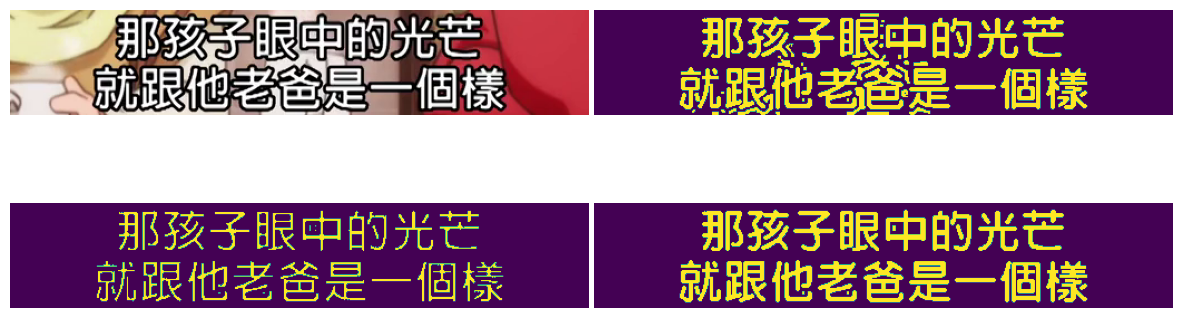

#### Base:
那孩子眼中的光芒
就跟他老爸是
个样
#### CV:
那孩子眼中的光芒
就跟他老爸是一个样
#### SAM:
那孩子眼中的光芒
就跟他老爸是个样
#### SAM:
那孩子眼中的光芒
就跟他老爸是一个样


/home/benji/coding/hunter_subs/utils.py:131: RuntimeWarning: invalid value encountered in divide
  out = max_abs_dist/frame_max_pixel


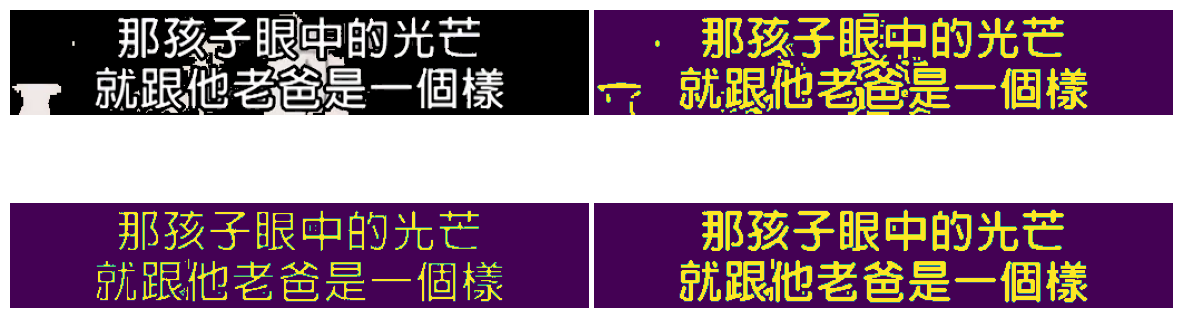

#### Base:
邹苾千眼卑阈
#### CV:
那孩子眼中的光芒
就跟他老爸是一个样
#### SAM:
那孩子眼中的光芒
就跟他老爸是一个样
#### SAM:
那孩子眼中的光芒
就跟牠老爸是一个样


In [6]:
n = 9120
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)


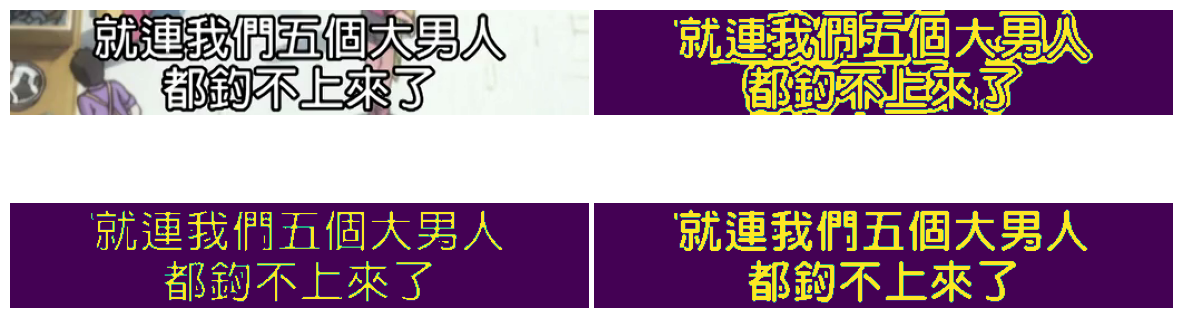

#### Base:
就连我们五个
3
都钓
上来
#### CV:
就遭墩椿;人
#### SAM:
就连我们五个大男/
都钓不二来了
#### SAM:
就连我们五个大男人
都钓不上来了


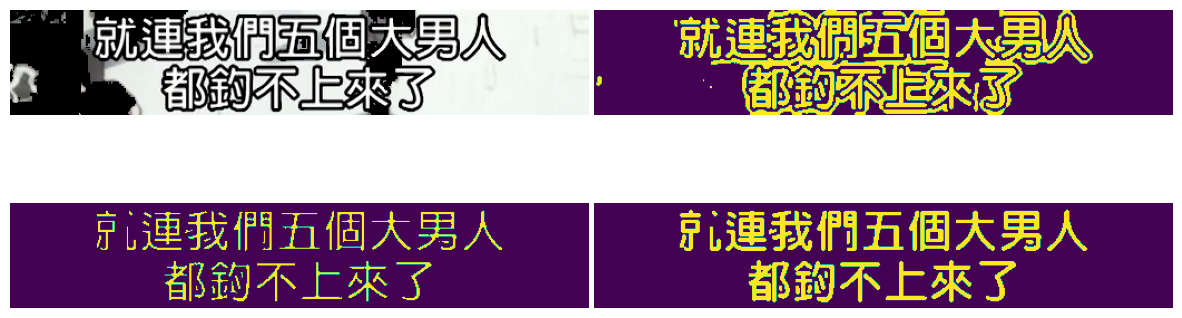

#### Base:

#### CV:
就连墩.;人
#### SAM:
京`连我们五个大男/
都钓不二来了
#### SAM:
京连我们五个大男人
都钓不上来了


In [7]:
n = 4750
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)


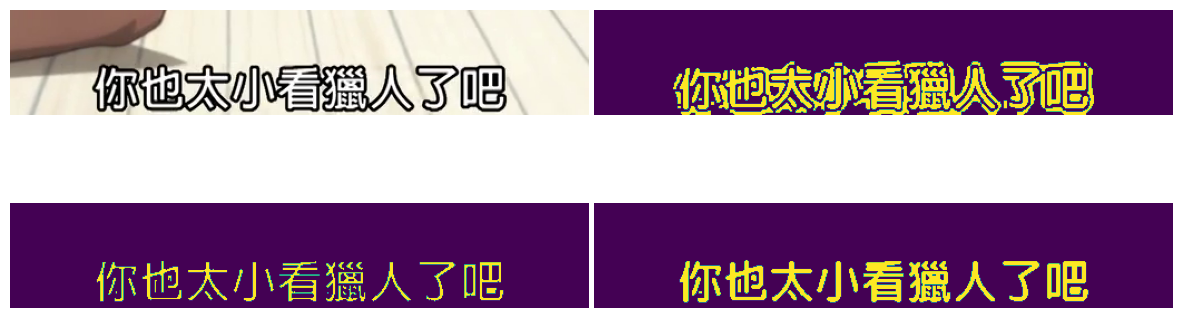

#### Base:
你也大叫看猎人5吧
#### CV:
你牠太小看猎人了吧
#### SAM:
你也太小看猎人了吧
#### SAM:
你也太小看猎人了吧


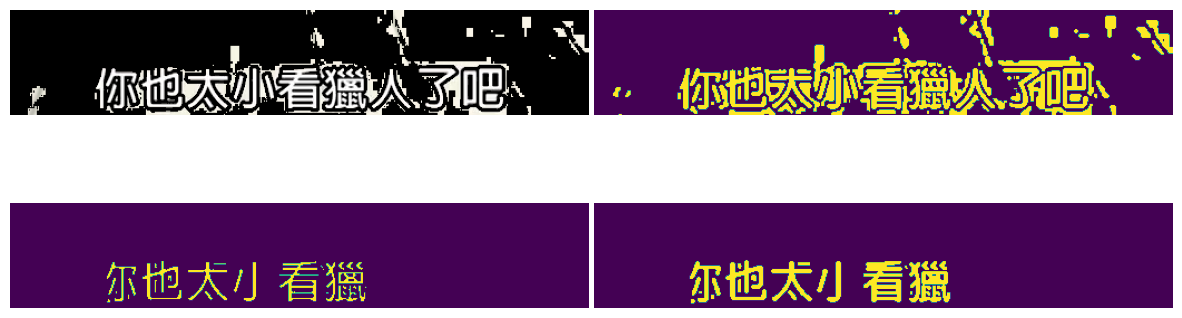

#### Base:

#### CV:
你牠求小看猎
#### SAM:
尔也太小看猎
#### SAM:
尔也太小看猎


In [25]:
n = 14450
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)


In [32]:
tokenizer, model = load_model("hfl/chinese-macbert-base")

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Some weights of the model checkpoint at hfl/chinese-macbert-base were not used when initializing BertForMaskedLM: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [33]:
score_sentence('你也太小看猎人了吧', tokenizer, model)
score_sentence('你牠太小看猎人了吧', tokenizer, model)

-0.19700687461429173

-0.3075267473856608

In [29]:
score_sentence('你也太小看猎人了吧', tokenizer, model)
score_sentence('你牠太小看猎人了吧', tokenizer, model)

-0.3297473324669732

-0.22395698229471842

In [34]:
score_sentence('你也太小看猎人', tokenizer, model)

-0.2972496577671596

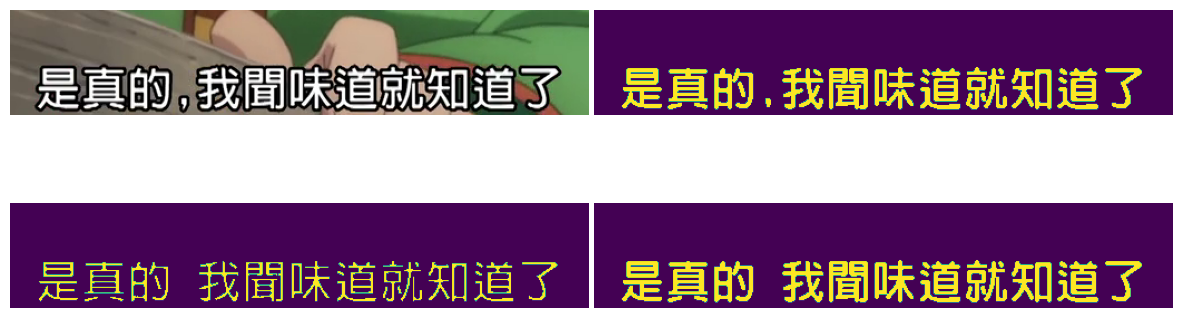

#### Base:
是真的,我闻味道就知道了
#### CV:
是真的,我闻味道就知道了
#### SAM:
是真的 我闻味道就知道了
#### SAM:
是真的 我闻味道就知道了


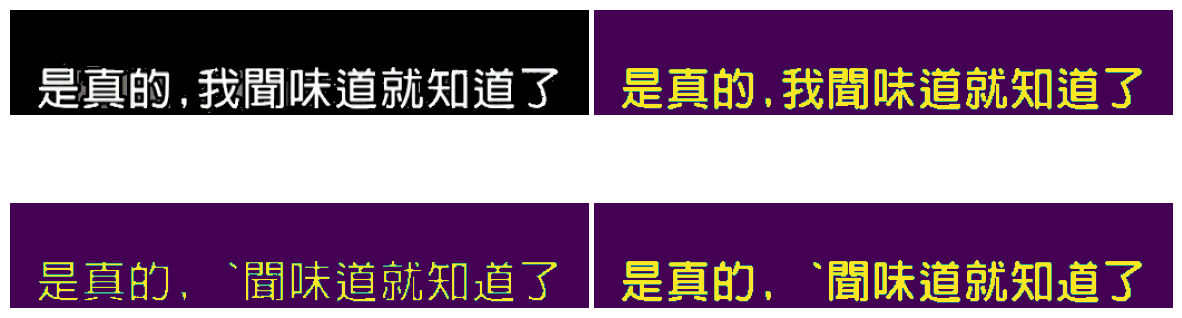

#### Base:
我闻味道就剁道`
#### CV:
是真的,我闻味道就知道了
#### SAM:
是真的
闻味道就知道了
#### SAM:
是真的
闻味道就知道了


In [24]:
n = 17400
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

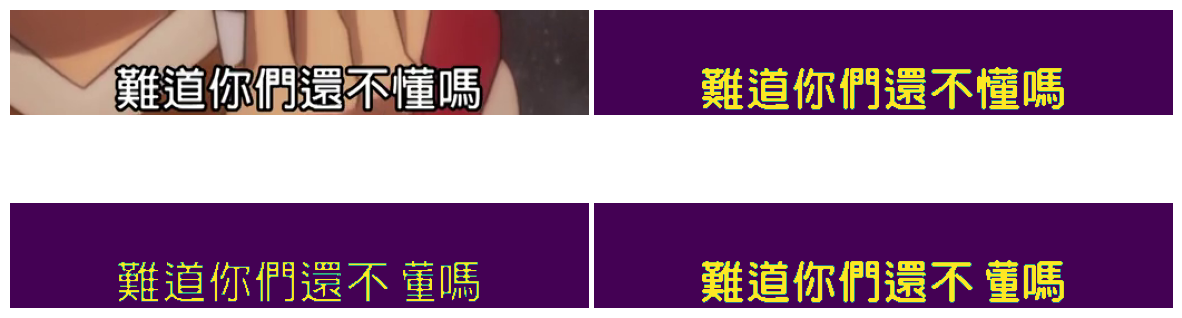

#### Base:
难道你们还不懂吗
#### CV:
难道你们还不懂吗
#### SAM:
难道你们还不董吗
#### SAM:
难道你们还不堇吗


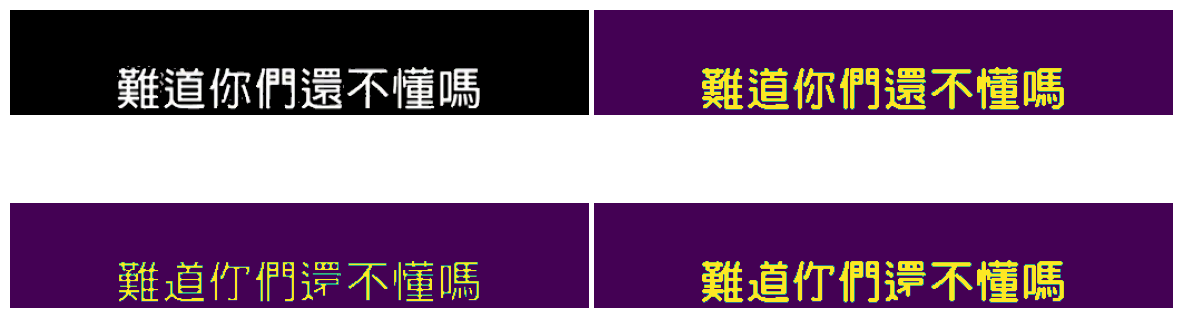

#### Base:
难道糊扪还`不懂
#### CV:
难道你们还不懂吗
#### SAM:
难道仃们谔不懂吗
#### SAM:
难道仃们还不懂吗


In [21]:
n = 25500
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

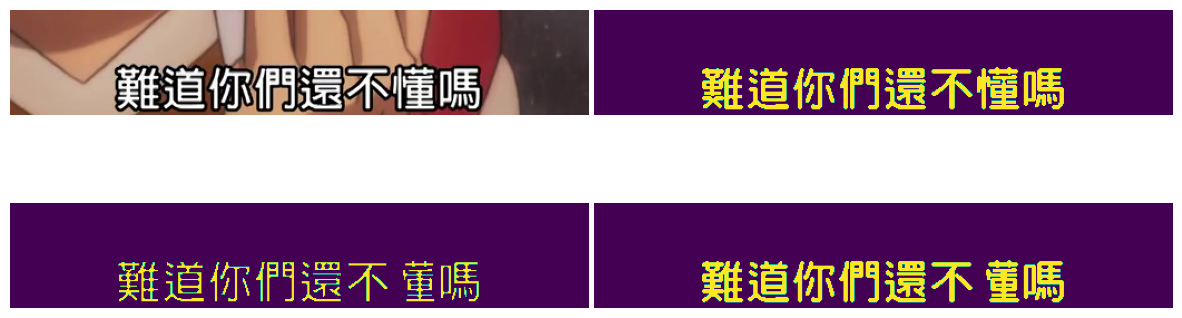

#### Base:
难道你们还不懂吗
#### CV:
难道你们还不懂吗
#### SAM:
难道你们还不董吗
#### SAM:
难道你们还不堇吗


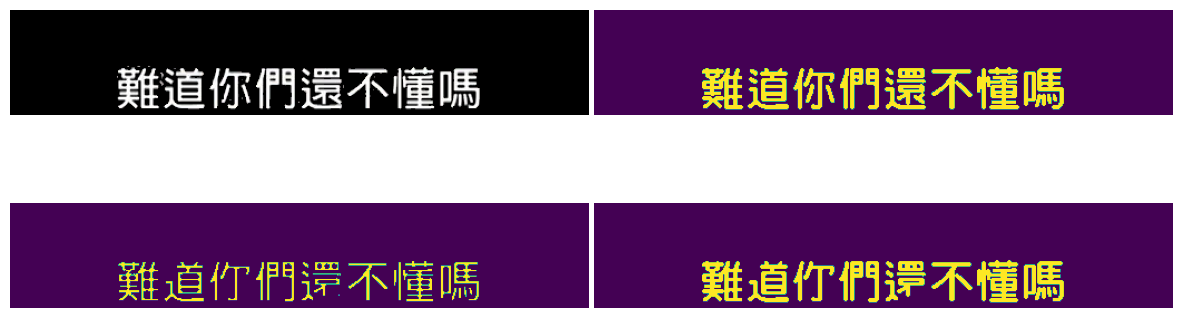

#### Base:
难道榔扪还`系懂吗
#### CV:
难道你们还不懂吗
#### SAM:
难道仃们还不懂吗
#### SAM:
难道竹们还不懂吗


In [23]:
n = 25465
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

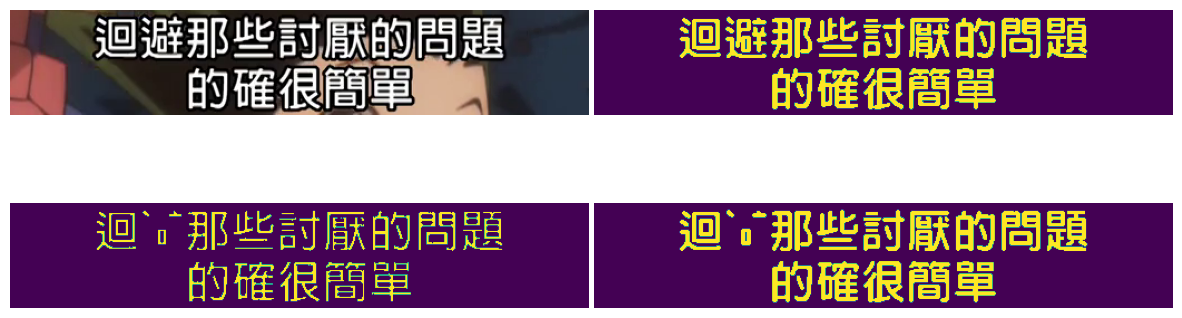

#### Base:
回避那些讨厌的问题
的确很简单
#### CV:
回避那些讨厌的问题
的确很简单
#### SAM:
回
那些讨厌的问题
的确很简单
#### SAM:
回
那些讨厌的问题
的确很简单


/home/benji/coding/hunter_subs/utils.py:131: RuntimeWarning: invalid value encountered in divide
  out = max_abs_dist/frame_max_pixel


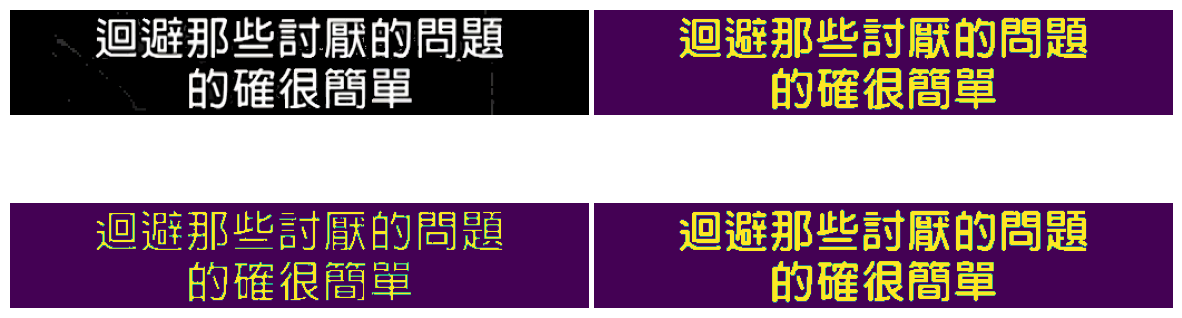

#### Base:
够:确很普单
#### CV:
回避那些讨厌的问题
的确很简单
#### SAM:
回避那些讨厌的问题
的确很简单
#### SAM:
回避那些讨厌的问题
的确很简单


In [35]:
n = 24400
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

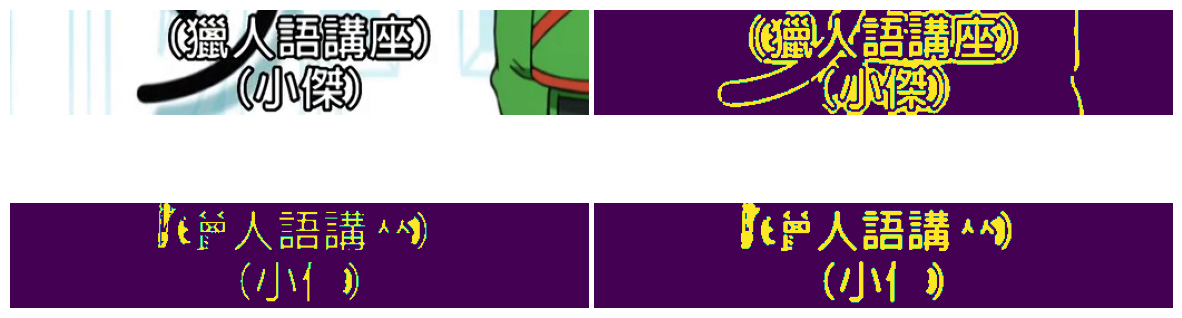

#### Base:

#### CV:
0
语讲座
#### SAM:
曾人语讲^^
(]1
#### SAM:
儿曾人语讲^^
(1


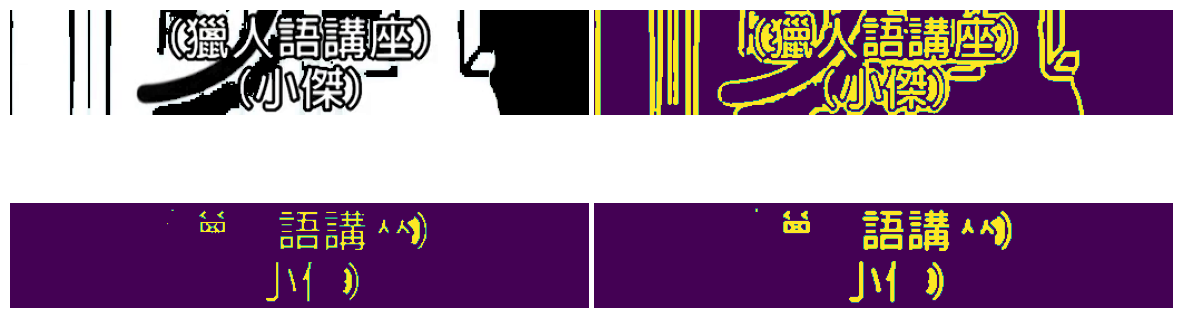

#### Base:

#### CV:
卜
语谶座
#### SAM:
蠃
语讲^^)
)
#### SAM:
6
语讲^^)


In [36]:
n = 19600
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

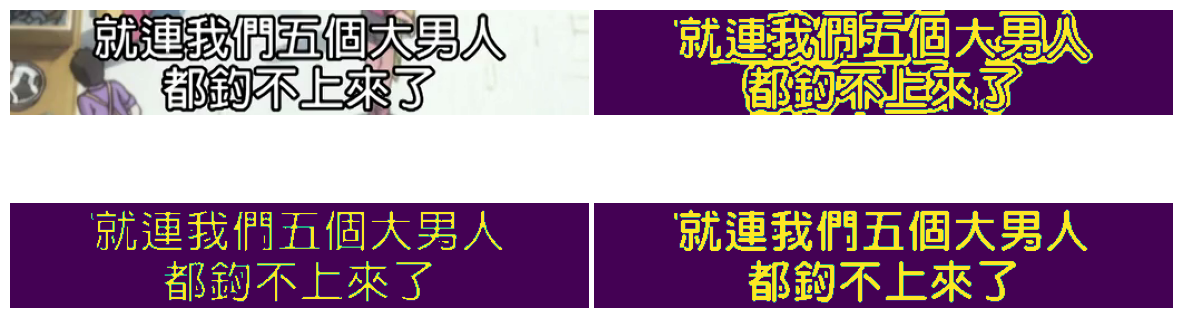

#### Base:
就连我们五个
3
都钓
上来
#### CV:
就遭墩椿;人
#### SAM:
就连我们五个大男/
都钓不二来了
#### SAM:
就连我们五个大男人
都钓不上来了


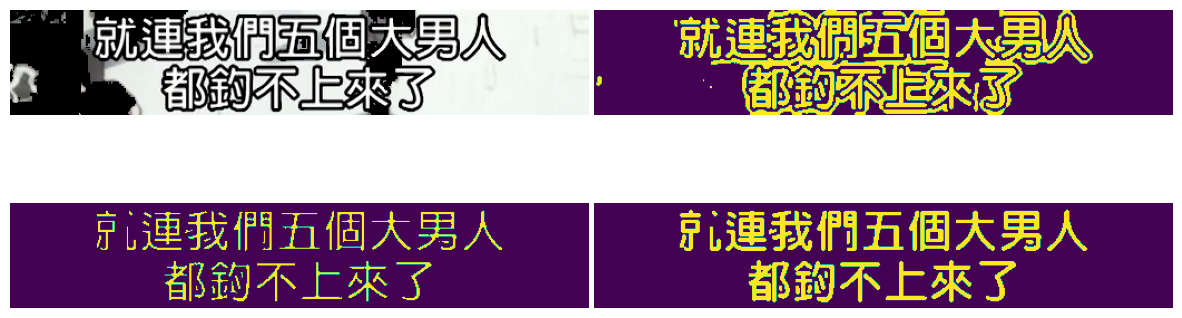

#### Base:

#### CV:
就连墩.;人
#### SAM:
京`连我们五个大男/
都钓不二来了
#### SAM:
京连我们五个大男人
都钓不上来了


In [37]:
n = 4750
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

In [39]:
score_sentence('就遭墩椿;人', tokenizer, model)
score_sentence('京连我们五个大男人\n都钓不上来了', tokenizer, model)

-1.1471612453460693

-0.10631085236867269

In [ ]:
score_sentence('就遭墩椿;人', tokenizer, model)
score_sentence('京连我们五个大男人\n都钓不上来了', tokenizer, model)

In [43]:
# get fps of video:
foo.cap.get(cv.CAP_PROP_FPS)

29.97002997002997

In [74]:
import pysubs2
# read the out.sub file, specifying fps
subs = pysubs2.load('ep1_v3/out.sub', encoding='utf-8', fps=foo.cap.get(cv.CAP_PROP_FPS))

In [80]:
subs[63].text

'我知道'

In [59]:
subs[50].text
subs[-30].text

'只要钓到了'

'散落而下的碎片.'

In [62]:
from tqdm import tqdm

texts = [sub.text for sub in subs[50:-30]]
scores = []
for text in tqdm(texts):
    scores.append(score_sentence(text, tokenizer, model))


100%|██████████| 658/658 [00:16<00:00, 40.71it/s]


(array([  2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   2.,   0.,   0.,   0.,  10.,   2.,   0.,   3.,   4.,   3.,
          2.,   2.,   4.,   5.,  13.,   4.,   4.,   9.,   2.,   9.,  12.,
         12.,  35.,  37.,  92., 138., 252.]),
 array([-10.82119083, -10.60575627, -10.3903217 , -10.17488714,
         -9.95945257,  -9.74401801,  -9.52858344,  -9.31314888,
         -9.09771431,  -8.88227975,  -8.66684518,  -8.45141062,
         -8.23597605,  -8.02054149,  -7.80510692,  -7.58967236,
         -7.37423779,  -7.15880323,  -6.94336866,  -6.7279341 ,
         -6.51249953,  -6.29706497,  -6.0816304 ,  -5.86619584,
         -5.65076127,  -5.43532671,  -5.21989214,  -5.00445758,
         -4.78902301,  -4.57358845,  -4.35815388,  -4.14271932,
         -3.92728475,  -3.71185019,  -3.49641562,  -3.28098106,
         -3.06554649,  -2.85011193,  -2.63467736,  -2.4192428 ,
         -2.203808

findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Source Han Sans CN' not found.
findfont: Font family 'Sourc

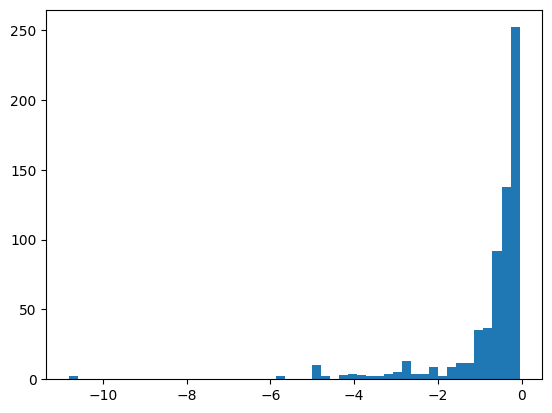

In [65]:
plt.hist(scores, bins=50)

In [73]:
score_sentence('可是;山|杰他爸钓到的时候', tokenizer, model)

-0.18227999026958758

In [70]:
outs = [(score, text) for score, text in zip(scores, texts) if score < -0.8 and len(text) > 5]
outs

[(-1.1471612453460693, '就遭墩椿;人'),
 (-1.0183653831481934, '相隔20年耶'),
 (-0.8390731130327497, '我荟好好努亦的'),
 (-0.9374641009739467, '你荟白白送死哦'),
 (-0.857688824335734, '=旨9-&山'),
 (-0.8796794414520264, '[869-&山'),
 (-1.1471612453460693, '就遭墩椿;人'),
 (-1.0183653831481934, '相隔20年耶'),
 (-0.8390731130327497, '我荟好好努亦的'),
 (-0.9374641009739467, '你荟白白送死哦')]

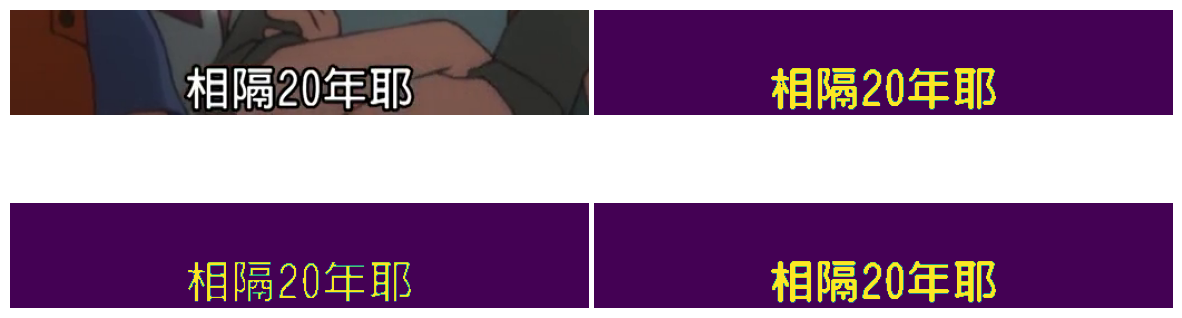

#### Base:
相隔20年耶
#### CV:
相隔20年耶
#### SAM:
相隔20年耶
#### SAM:
相隔20年耶


In [71]:
n = 7220
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
# frame2 = frame.copy()
# frame2 = utils.blacken_colored_pixels(frame2)
# ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)

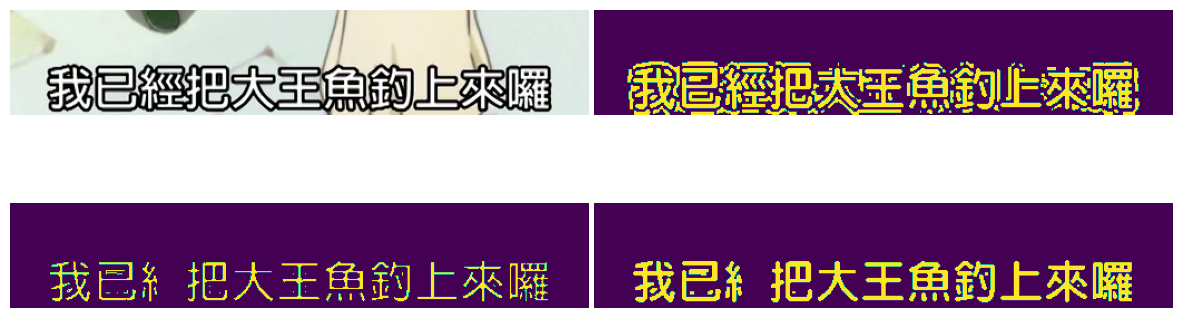

#### Base:
我已经把大王鱼钓上来啰
#### CV:
我己经把犬玉鱼钓止来啰
#### SAM:
我巳丝把六王鱼钓上来啰
#### SAM:
我已糸把大王鱼钓上来啰


/home/benji/coding/hunter_subs/utils.py:131: RuntimeWarning: invalid value encountered in divide
  out = max_abs_dist/frame_max_pixel


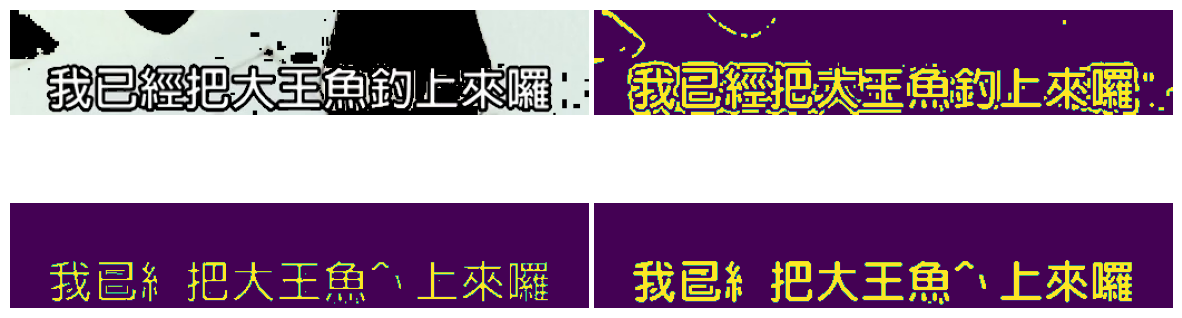

#### Base:
经把大歪鱼弑上来啰
#### CV:
我已经把求王鱼钓|上来啰"
#### SAM:
我邑丝把大王鱼^上来啰
#### SAM:
我已糸把大王鱼
上来啰


In [72]:
n = 7799
ret, frame = utils.get_frame_n(foo.cap, n)
frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame_n2(sam, foo.cap, n)
frame2 = frame.copy()
frame2 = utils.blacken_colored_pixels(frame2)
ocr, ocr_cv, ocr_sam, ocr_sam_grow = utils.quick_process_frame(sam, frame2)